# 01 기준선 모델과 홀드아웃 검증

목적: 비교사례 보정·ML 같은 복잡한 모델을 만들기 전에 **가장 단순한 추정이 얼마나 맞는지** 기준선을 세운다.
설계는 `docs/의사결정/1007_07_분석_문제_정의.md`.

| 기준선 | 방법 |
|---|---|
| B0 ㎡단가 | 시점 보정한 ㎡당 단가 중앙값(같은 건물 → 법정동 → 구) × 전용면적 |
| B1 공시비율 | 같은 호 공시가격 × 시점 보정한 실거래가/공시가격 비율 중앙값(같은 건물 → 법정동 → 구) |

검증: 최근 12개월 거래가 있는 평가 권역 건물의 20%(시드 42)를 검증 건물로 고정, 건물마다 최근 거래 1건을 입력처럼 넣는다(호 없음, 면적 있음).
- A: 검증 건물의 거래를 모두 학습에서 뺌(처음 보는 건물)
- B: 검증 건물의 대상 거래 이전 거래만 남김(같은 건물 과거 거래 있음)


In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from avm import load_refs, holdout_split, holdout_targets, run_holdout, evaluate, TimeIndex, SGG_NAME
plt.rcParams["font.family"] = "Malgun Gothic"; plt.rcParams["axes.unicode_minus"] = False
OUT = ROOT / "outputs"; OUT.mkdir(exist_ok=True)
refs = load_refs()
# 검증 건물은 한 번 뽑아 고정한다(1007_07). 정제 규칙이 바뀌어 거래가 달라져도 같은 건물로 비교하도록 파일을 읽는다
HOLDOUT = ROOT / "data/processed/holdout_pnu.csv"
if HOLDOUT.exists():
    test_pnu = pd.read_csv(HOLDOUT, dtype=str)["pnu"]
else:
    test_pnu = holdout_split(refs.trades)
    test_pnu.to_csv(HOLDOUT, index=False)
targets = holdout_targets(refs.trades, test_pnu)
print(f"검증 건물 {len(test_pnu)}개, 대상 거래 {len(targets)}건")
targets.assign(권역=targets.sgg_cd.map(SGG_NAME)).groupby("권역").size()

검증 건물 632개, 대상 거래 632건


권역
강남구    133
강서구    262
관악구    237
dtype: int64

## 1. 시점 지수

구별로 log(실거래가/2026 공시가격)의 월 중앙값을 3개월 이동평균. 2026-09·10월은 신고기한 전이라 제외하고 2026-08을 기준(0)으로 둔다.

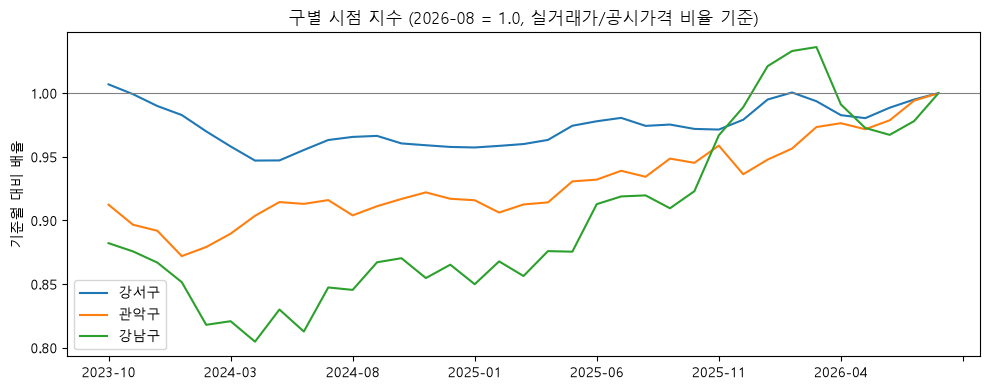

,강서구,관악구,강남구
2023-10,1.007,0.912,0.882
2024-10,0.961,0.917,0.870
2025-10,0.972,0.945,0.923
2026-08,1.000,1.000,1.000


In [2]:
ti_all = TimeIndex().fit(refs.trades)
idx = ti_all.table()
rel = idx - idx.iloc[-1]                      # 기준월 대비 로그 차이
rel.columns = [SGG_NAME[c] for c in rel.columns]
np.exp(rel).round(4).to_csv(OUT / "time_index.csv", encoding="utf-8-sig")  # 기준월 대비 배율
ax = np.exp(rel).plot(figsize=(10, 4), title="구별 시점 지수 (2026-08 = 1.0, 실거래가/공시가격 비율 기준)")
ax.axhline(1, color="gray", lw=0.8); ax.set_ylabel("기준월 대비 배율"); plt.tight_layout(); plt.show()
np.exp(rel).iloc[list(range(0, len(rel) - 1, 12)) + [-1]].round(3)  # 12개월 간격 + 마지막 달(학습 기간 TRAIN_YEARS에 맞춰)

## 2. 기준선 비교

In [3]:
runs = {}
for sc in "AB":
    for name, use_public in [("B0 ㎡단가", False), ("B1 공시비율", True)]:
        runs[(sc, name)] = run_holdout(refs, sc, use_public=use_public, test_pnu=test_pnu)
metrics = pd.DataFrame({k: evaluate(v) for k, v in runs.items()}).T
metrics.index.names = ["상황", "기준선"]
metrics.to_csv(OUT / "baseline_metrics.csv", encoding="utf-8-sig")
metrics.style.format({"n": "{:.0f}", "MAPE": "{:.1%}", "중앙값APE": "{:.1%}", "±10%": "{:.1%}", "±20%": "{:.1%}", "80%구간포함률": "{:.1%}"})

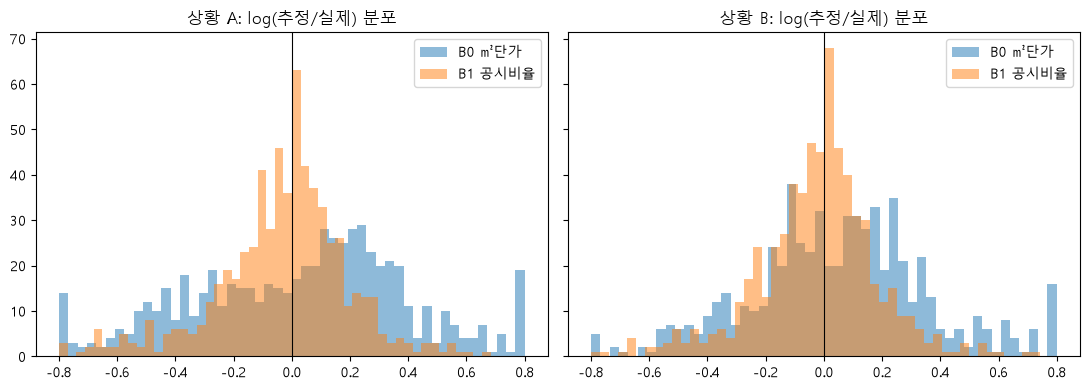

In [4]:
pred = pd.concat({k: v for k, v in runs.items()}, names=["상황", "기준선"]).reset_index(level=[0, 1])
pred.to_csv(OUT / "baseline_predictions.csv", index=False, encoding="utf-8-sig")
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, sc in zip(axes, "AB"):
    for name in ["B0 ㎡단가", "B1 공시비율"]:
        e = pred[(pred.상황 == sc) & (pred.기준선 == name)].log_err
        ax.hist(e.clip(-0.8, 0.8), bins=50, alpha=0.5, label=name)
    ax.axvline(0, color="k", lw=0.8); ax.set_title(f"상황 {sc}: log(추정/실제) 분포"); ax.legend()
plt.tight_layout(); plt.show()

## 3. 권역·근거 수준별 오차 (B1, 상황 B)

In [5]:
b = runs[("B", "B1 공시비율")].copy()
b["권역"] = b.sgg_cd.map(SGG_NAME)
by_area = b.groupby("권역").apply(evaluate)
by_tier = b.groupby(["method", "tier"]).apply(evaluate)
display(by_area.style.format("{:.3f}")); display(by_tier.style.format("{:.3f}"))

,n,MAPE,중앙값APE,±10%,±20%,80%구간포함률
권역,,,,,,
강남구,133.000,0.174,0.127,0.391,0.692,0.692
강서구,262.000,0.137,0.100,0.500,0.767,0.664
관악구,237.000,0.143,0.099,0.511,0.734,0.684


## 4. 신뢰도와 실제 오차

블라인드 평가는 신뢰도가 오차와 맞는지를 본다. 신뢰도가 높을수록 오차가 작아야 한다(단조 감소).

In [6]:
for sc in "AB":
    p = runs[(sc, "B1 공시비율")]
    t = p.groupby(pd.cut(p.confidence, [0, 0.4, 0.55, 0.7, 0.85, 1.0])).agg(n=("ape", "size"), 중앙값APE=("ape", "median"), MAPE=("ape", "mean"))
    print(f"상황 {sc}"); display(t.style.format({"중앙값APE": "{:.1%}", "MAPE": "{:.1%}"}))

상황 A


,n,중앙값APE,MAPE
confidence,,,
"(0.4, 0.55]",3,31.0%,25.7%
"(0.55, 0.7]",629,11.1%,15.8%


상황 B


,n,중앙값APE,MAPE
confidence,,,
"(0.4, 0.55]",2,35.6%,35.6%
"(0.55, 0.7]",253,11.7%,16.1%
"(0.7, 0.85]",377,9.6%,13.6%


## 5. 오차가 큰 사례 (B1, 상황 B)

In [7]:
cols = ["dong", "pnu", "deal_date", "price", "actual", "price_est", "ape", "tier", "n", "basis"]
b.sort_values("ape", ascending=False)[cols].head(10)

,dong,pnu,deal_date,price,actual,price_est,ape,tier,n,basis
565,대치동,1168010600109530025,2026-08-22,180000000,1.800000e+08,3.788057e+08,1.104476,같은 건물,9,"공시가격 1.59억 × 실거래/공시 비율 2.38(같은 건물 9건+법정동, 기준일 ..."
279,청담동,1168010400100690019,2026-04-13,387200000,3.888572e+08,7.772246e+08,0.998740,같은 건물,1,"공시가격 4.47억 × 실거래/공시 비율 1.74(같은 건물 1건+법정동, 기준일 ..."
378,봉천동,1162010100100410147,2026-05-20,205000000,2.104581e+08,3.864657e+08,0.836307,법정동,1701,"공시가격 2.13억 × 실거래/공시 비율 1.81(법정동 1701건, 기준일 시점보정)"
490,화곡동,1150010300103420083,2026-07-14,123650000,1.241929e+08,2.214435e+08,0.783062,같은 건물,2,"공시가격 1.30억 × 실거래/공시 비율 1.70(같은 건물 2건+법정동, 기준일 ..."
309,봉천동,1162010100106350337,2026-04-23,180000000,1.842584e+08,3.193332e+08,0.733072,법정동,1701,"공시가격 1.76억 × 실거래/공시 비율 1.81(법정동 1701건, 기준일 시점보정)"
628,화곡동,1150010300109960019,2026-09-23,200000000,2.000000e+08,3.421211e+08,0.710606,같은 건물,4,"공시가격 1.89억 × 실거래/공시 비율 1.81(같은 건물 4건+법정동, 기준일 ..."
425,화곡동,1150010300100560429,2026-06-16,80000000,8.087420e+07,1.381996e+08,0.708821,법정동,4751,"공시가격 0.82억 × 실거래/공시 비율 1.69(법정동 4751건, 기준일 시점보정)"
596,개포동,1168010300112550004,2026-09-07,522560000,5.225600e+08,8.525954e+08,0.631574,법정동,472,"공시가격 3.89억 × 실거래/공시 비율 2.19(법정동 472건, 기준일 시점보정)"
75,화곡동,1150010300104100226,2025-12-16,55000000,5.660180e+07,9.213304e+07,0.627741,법정동,4751,"공시가격 0.55억 × 실거래/공시 비율 1.69(법정동 4751건, 기준일 시점보정)"
78,삼성동,1168010500100950006,2025-12-17,1700000000,1.683786e+09,2.706396e+09,0.607328,법정동,136,"공시가격 14.06억 × 실거래/공시 비율 1.92(법정동 136건, 기준일 시점보정)"


## 6. 관찰

결과 수치는 위 표에서 읽고, 해석과 다음 단계는 `docs/의사결정/1007_08_기준선_모델.md`에 정리한다.